<a href="https://colab.research.google.com/github/harshgillmain9773-ops/Santimental_analysisof-financialnews/blob/main/B5_%7C_Sentiment_Analysis_on_Financial_News_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1 : EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re      # Used for regular expression(text cleaning)

In [ ]:
df = pd.read_csv('/content/all-data.csv',encoding='latin1',names=['sentiment','text'])
df

,sentiment,text
0,neutral,"According to Gran , the company has no plans t..."
1,neutral,Technopolis plans to develop in stages an area...
2,negative,The international electronic industry company ...
3,positive,With the new production plant the company woul...
4,positive,According to the company 's updated strategy f...
...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...
4844,negative,Net sales of the Paper segment decreased to EU...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4846 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4846 non-null   object
 1   text       4846 non-null   object
dtypes: object(2)
memory usage: 75.8+ KB


In [ ]:
df.duplicated().sum()

np.int64(6)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4840 entries, 0 to 4845
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  4840 non-null   object
 1   text       4840 non-null   object
dtypes: object(2)
memory usage: 113.4+ KB


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
neutral,2873
positive,1363
negative,604


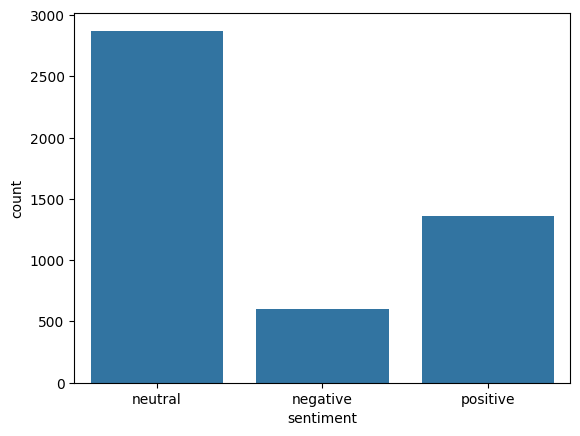

In [ ]:
sns.countplot(df,x='sentiment')
plt.show()

In [ ]:
df.sample(10)

,sentiment,text
4246,neutral,The company has a continuous need for alloys s...
3856,neutral,The government started the sell-off last month...
3653,neutral,It posted a turnover of 4.5 mln euro $ 6.1 mln...
2801,neutral,An earn-out payment of up to 4.0 mln euro ( $ ...
959,positive,Operating profit improved by 16.7 % to EUR 7.7...
2919,neutral,F-Secure reported that : - The first half of 2...
489,positive,Finnish lifting equipment maker Konecranes HEL...
2294,positive,"Outokumpu of Finland , stainless steel manufac..."
4551,negative,The total need for staff cuts corresponds to a...
626,positive,`` The acquisition of Elektros Pavara complete...


## Step 2 : Text Preporcessing

In [ ]:
# !pip install nltk
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'itself', 'having', "she's", 'be', 'has', "it'd", 'that', 'off', 'hasn', 'was', 'am', 'until', 'an', 'theirs', 'there', 'm', "you've", 'before', 'same', 'i', 'doesn', 'each', "needn't", 'to', 'with', "it'll", "you'd", 'haven', 'll', "he'll", 'his', 'ourselves', "don't", 'ours', "shan't", 'no', "she'll", 'he', 'which', 've', 'just', 'both', 'him', 'mustn', 'yourself', 'again', 'does', 'any', 'wasn', "that'll", 'this', "doesn't", 'why', 'how', 'over', 'where', 'your', 'by', 'themselves', "you'll", 'a', 'will', 'needn', "mustn't", "hasn't", 'should', 'than', 'their', "he's", 'through', 'nor', 'between', 'herself', 'own', 'she', 'been', 'aren', 's', 'hers', 'if', "i'm", 'more', 'shan', 'and', "couldn't", 'as', 'these', 'out', "isn't", 'of', "we'll", 'at', "haven't", "shouldn't", 'such', 'under', 'or', "should've", "he'd", "we're", "didn't", 'other', 'above', 'while', 'didn', 'during', 'them', 'yours', 'our', 'here', 'from', 'me', 'in', 'don', 'now', "she'd", 't', 're', 'ain', 'so', 'did',

In [ ]:
stemmer = PorterStemmer()

In [ ]:
# Funciton for text cleaning
def clean_text(text):
  text = text.lower()

  text = re.sub(r'\d+','',text)
  text = re.sub(r'[^\w\s]','',text)
  text = re.sub(r'\s+',' ',text).strip()

  words = text.split()

  cleaned_words = []
  for word in words:
    if word not in stop_words:
      word = stemmer.stem(word)
      cleaned_words.append(word)

  cleaned_text = " ".join(cleaned_words)

  return cleaned_text

In [ ]:
df['cleaned_text'] = df['text'].apply(clean_text)

/tmp/ipykernel_1269/3867957871.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cleaned_text'] = df['text'].apply(clean_text)


In [ ]:
df

,sentiment,text,cleaned_text
0,neutral,"According to Gran , the company has no plans t...",accord gran compani plan move product russia a...
1,neutral,Technopolis plans to develop in stages an area...,technopoli plan develop stage area less squar ...
2,negative,The international electronic industry company ...,intern electron industri compani elcoteq laid ...
3,positive,With the new production plant the company woul...,new product plant compani would increas capac ...
4,positive,According to the company 's updated strategy f...,accord compani updat strategi year baswar targ...
...,...,...,...
4841,negative,LONDON MarketWatch -- Share prices ended lower...,london marketwatch share price end lower londo...
4842,neutral,Rinkuskiai 's beer sales fell by 6.5 per cent ...,rinkuskiai beer sale fell per cent million lit...
4843,negative,Operating profit fell to EUR 35.4 mn from EUR ...,oper profit fell eur mn eur mn includ vessel s...
4844,negative,Net sales of the Paper segment decreased to EU...,net sale paper segment decreas eur mn second q...


In [ ]:
(df['cleaned_text'] == '').sum()

np.int64(1)

In [ ]:
df = df[df['cleaned_text'] != '']

In [ ]:
(df['cleaned_text'] == '').sum()

np.int64(0)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
df['sentiment_label'] = label_encoder.fit_transform(df['sentiment'])

/tmp/ipykernel_1269/2330511877.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sentiment_label'] = label_encoder.fit_transform(df['sentiment'])


In [ ]:
# 0 = Negative
# 1 = Neutral
# 2 = Positive

In [ ]:
x = df['cleaned_text']
y = df['sentiment_label']

In [ ]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state = 42)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()

In [ ]:
x_train_tfidf = tfidf.fit_transform(x_train)

In [ ]:
x_test_tfidf = tfidf.transform(x_test)

## Step 3 : Model Training and Evaluation

In [ ]:
# Import Classificatoin Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Import Evaluation Metrics
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix

### Model-1 :Logistic Regression

In [ ]:
lr_model = LogisticRegression()
# x_train_tfidf, x_test_tfidf, y_train, y_test

lr_model.fit(x_train_tfidf,y_train)

LogisticRegression()

In [ ]:
lr_pred = lr_model.predict(x_test_tfidf)

In [ ]:
lr_accuracy = accuracy_score(y_test,lr_pred)
print(lr_accuracy)

0.734504132231405


In [ ]:
cm = confusion_matrix(y_test,lr_pred)
cm

array([[ 40,  62,  15],
       [  4, 539,  22],
       [ 11, 143, 132]])

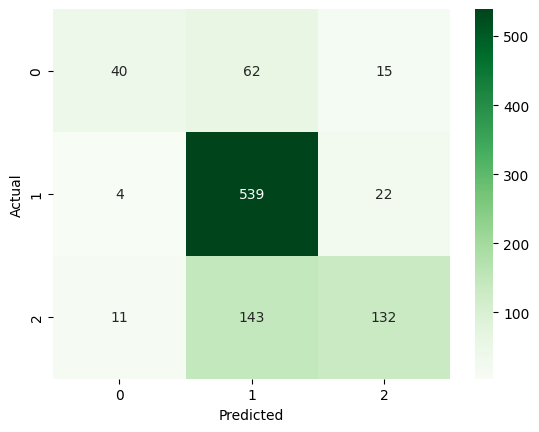

In [ ]:
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       0.73      0.34      0.47       117
           1       0.72      0.95      0.82       565
           2       0.78      0.46      0.58       286

    accuracy                           0.73       968
   macro avg       0.74      0.59      0.62       968
weighted avg       0.74      0.73      0.71       968



### Model 2 - Naive Bayes Classifier

In [ ]:
nb_model = MultinomialNB()

In [ ]:
nb_model.fit(x_train_tfidf,y_train)

MultinomialNB()

In [ ]:
nb_pred = nb_model.predict(x_test_tfidf)

In [ ]:
nb_accuracy = accuracy_score(y_test, nb_pred)
nb_accuracy

0.6735537190082644

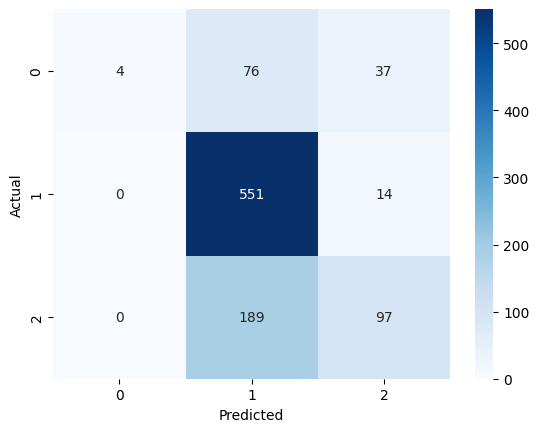

In [ ]:
cm=confusion_matrix(y_test, nb_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Model 3 - Decision Tree Classifier

In [ ]:
dt_model = DecisionTreeClassifier()

In [ ]:
dt_model.fit(x_train_tfidf,y_train)

DecisionTreeClassifier()

In [ ]:
dt_pred = dt_model.predict(x_test_tfidf)

In [ ]:
dt_accuracy = accuracy_score(y_test,dt_pred)
dt_accuracy

0.7076446280991735

### Model 4 - Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train_tfidf,y_train)

RandomForestClassifier()

In [ ]:
rf_pred=rf_model.predict(x_test_tfidf)
rf_accuracy = accuracy_score(y_test,rf_pred)
rf_accuracy

0.7582644628099173

### Model 5 - SVM

In [ ]:
svm_model = SVC()

In [ ]:
svm_model.fit(x_train_tfidf,y_train)

SVC()

In [ ]:
svm_pred = svm_model.predict(x_test_tfidf)
svm_accuracy = accuracy_score(y_test,svm_pred)
svm_accuracy

0.7241735537190083

### Model 6 - KNN

In [ ]:
knn_model = KNeighborsClassifier()
knn_model.fit(x_train_tfidf,y_train)

KNeighborsClassifier()

In [ ]:
knn_pred = knn_model.predict(x_test_tfidf)
knn_accuracy = accuracy_score(y_test,knn_pred)
knn_accuracy

0.6694214876033058

In [ ]:
accuracy_scores = {'Logistic Regression':lr_accuracy,
                   'Navie Bayes':nb_accuracy,
                   'Decision Tree':dt_accuracy,
                   'Random Forest':rf_accuracy,
                   'Support Vector Machine':svm_accuracy,
                   'K-Nearest Neighbors':knn_accuracy}

acc_df = pd.DataFrame(accuracy_scores.items(),columns=['Model','Accuracy'])
acc_df

,Model,Accuracy
0,Logistic Regression,0.734504
1,Navie Bayes,0.673554
2,Decision Tree,0.707645
3,Random Forest,0.758264
4,Support Vector Machine,0.724174
5,K-Nearest Neighbors,0.669421


In [ ]:
acc_df = acc_df.sort_values(by='Accuracy',ascending=False)

<Axes: xlabel='Accuracy', ylabel='Model'>

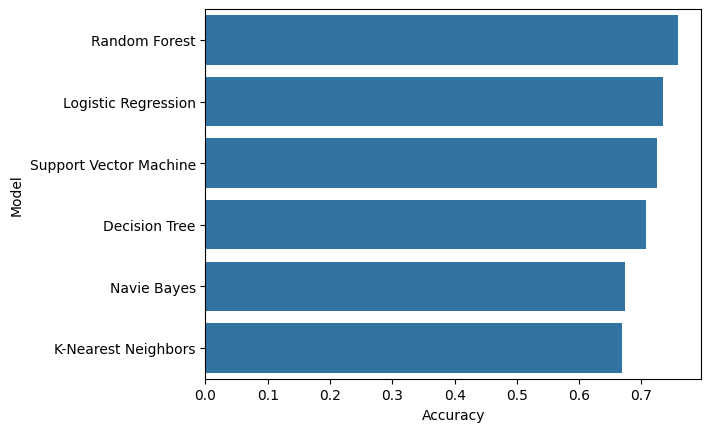

In [ ]:
sns.barplot(acc_df,y='Model',x='Accuracy')

In [ ]:
print(f'Random Forest has the highest accuracy score : {rf_accuracy}')

Random Forest has the highest accuracy score : 0.7582644628099173


In [ ]:
def predict_sentiment(text):
  cleaned = clean_text(text)
  vector = tfidf.transform([cleaned])
  prediction = rf_model.predict(vector)
  sentiment = label_encoder.inverse_transform(prediction)
  return sentiment[0]

In [ ]:
text='I hated this product. this is so bad.'
print(predict_sentiment(text))

neutral
